# Datos Boston Housing (Corrected)

Este dataset es una versión revisada del trabajo original de **Harrison y Rubinfeld (1978)**. Incluye correcciones de errores menores identificados por Gilley y Pace (1996) y añade coordenadas geográficas para análisis espacial.

## 1. Información General
* **Contexto:** Estudio sobre la demanda de aire limpio y su incidencia en el valor de la vivienda.
* **Observaciones:** 506 sectores censales (tracts).
* **Atributos:** 21 variables (geográficas, sociales, económicas y ambientales).

---

## 2. Diccionario de Variables

### Identificadores y Geografía
| Variable | Descripción |
| :--- | :--- |
| **TOWN** | Nombre de la población o ciudad en el área de Boston. |
| **LON / LAT** | Longitud y Latitud de la observación (coordenadas geográficas). |
| **TRACT** | Código del sector censal. |

### Variables de Valor (Target sugerido)
| Variable | Descripción |
| :--- | :--- |
| **MEDV** | Valor mediano de las viviendas ocupadas por sus propietarios (en \$1,000s). |
| **CMEDV** | Valor mediano corregido de las viviendas (recomendado para modelos). |

### Factores Socioeconómicos y Estructurales
| Variable | Descripción |
| :--- | :--- |
| **CRIM** | Tasa de criminalidad per cápita por ciudad. |
| **ZN** | Proporción de suelo residencial para lotes grandes (>25,000 sq.ft.). |
| **INDUS** | Proporción de acres comerciales no minoristas por ciudad. |
| **CHAS** | Variable Dummy del río Charles (= 1 si limita con el río; 0 si no). |
| **RM** | Número promedio de habitaciones por vivienda. |
| **AGE** | Proporción de unidades construidas antes de 1940. |
| **DIS** | Distancias ponderadas a cinco centros de empleo de Boston. |
| **RAD** | Índice de accesibilidad a carreteras radiales. |
| **TAX** | Tasa de impuesto a la propiedad por cada \$10,000. |
| **PTRATIO** | Relación alumno-profesor por ciudad. |
| **B** | Cálculo basado en la proporción de población afrodescendiente ($1000(Bk - 0.63)^2$). |
| **LSTAT** | Porcentaje de población de estatus socioeconómico bajo. |

### Factor Ambiental
| Variable | Descripción |
| :--- | :--- |
| **NOX** | Concentración de óxidos de nitrógeno (partes por 10 millones). |

---

# Carga de Datos

In [62]:
import pandas as pd
df = pd.read_csv("boston_corrected.txt", sep='\t', skiprows=7, encoding='latin-1')
df

,OBS.,TOWN,TOWN#,TRACT,LON,LAT,MEDV,CMEDV,CRIM,ZN,...,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,1,Nahant,0,2011,-70.9550,42.2550,24.0,24.0,0.00632,18.0,...,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,2,Swampscott,1,2021,-70.9500,42.2875,21.6,21.6,0.02731,0.0,...,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,3,Swampscott,1,2022,-70.9360,42.2830,34.7,34.7,0.02729,0.0,...,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,4,Marblehead,2,2031,-70.9280,42.2930,33.4,33.4,0.03237,0.0,...,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,5,Marblehead,2,2032,-70.9220,42.2980,36.2,36.2,0.06905,0.0,...,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,502,Winthrop,91,1801,-70.9860,42.2312,22.4,22.4,0.06263,0.0,...,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,503,Winthrop,91,1802,-70.9910,42.2275,20.6,20.6,0.04527,0.0,...,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,504,Winthrop,91,1803,-70.9948,42.2260,23.9,23.9,0.06076,0.0,...,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,505,Winthrop,91,1804,-70.9875,42.2240,22.0,22.0,0.10959,0.0,...,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


# Exploracion de datos

In [63]:
df.isnull().sum()

,0
OBS.,0
TOWN,0
TOWN#,0
TRACT,0
LON,0
LAT,0
MEDV,0
CMEDV,0
CRIM,0
ZN,0


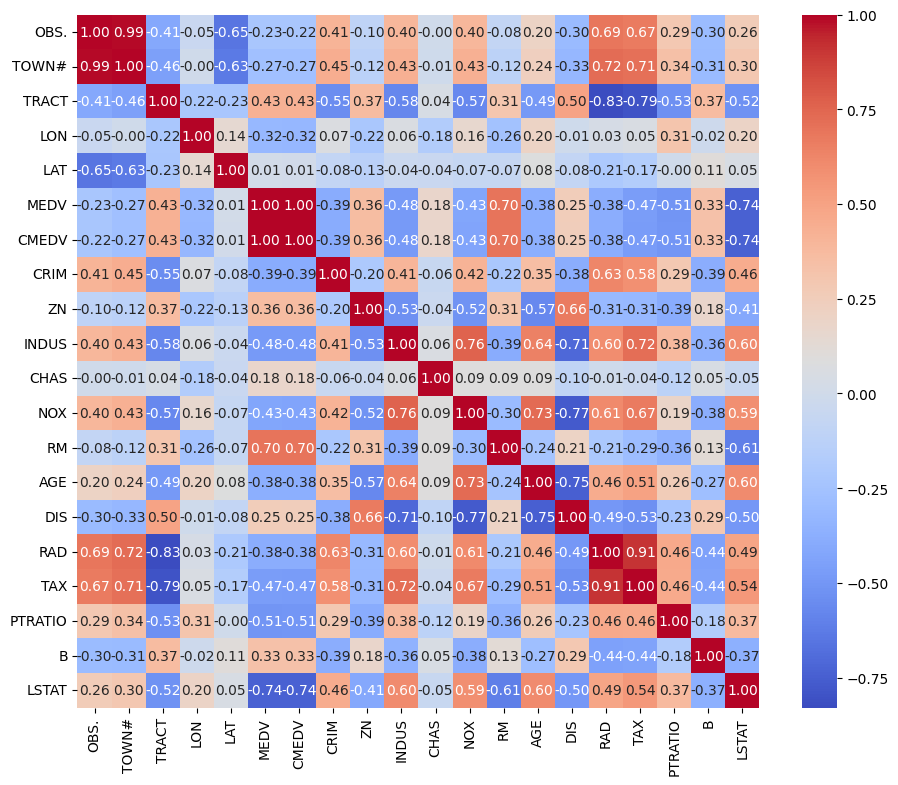

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11,9))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")
plt.show()

Como lo que estamos prediciendo Inicialmente es **CRIM** cojamos las variables que mejor se ajusten para hacer los modelos:

Variables con CRIM

In [81]:
corr_crim = df.corr(numeric_only=True)['CRIM'].sort_values(ascending=False)

print("Variables que se mueven igual que CRIM (Positivas):")
print(corr_crim.head(7))

print("\nVariables que se mueven opuesto a CRIM (Negativas):")
print(corr_crim.tail(7))

Variables que se mueven igual que CRIM (Positivas):
CRIM     1.000000
RAD      0.625505
TAX      0.582764
LSTAT    0.455621
TOWN#    0.447920
NOX      0.420972
OBS.     0.407407
Name: CRIM, dtype: float64

Variables que se mueven opuesto a CRIM (Negativas):
ZN      -0.200469
RM      -0.219247
DIS     -0.379670
B       -0.385064
MEDV    -0.388305
CMEDV   -0.389582
TRACT   -0.547165
Name: CRIM, dtype: float64


Variables con **CMEDV** que es la que usaremos despues

In [122]:
corr_cmedv = df.corr(numeric_only=True)['CMEDV'].sort_values(ascending=False)

print("Variables que se mueven igual que CMEDV (Positivas):")
print(corr_cmedv.head(7))

print("\nVariables que se mueven opuesto a CMEDV (Negativas):")
print(corr_cmedv.tail(7))

Variables que se mueven igual que CMEDV (Positivas):
CMEDV    1.000000
MEDV     0.998476
RM       0.696304
TRACT    0.428252
ZN       0.360386
B        0.334861
DIS      0.249315
Name: CMEDV, dtype: float64

Variables que se mueven opuesto a CMEDV (Negativas):
RAD       -0.384766
CRIM      -0.389582
NOX       -0.429300
TAX       -0.471979
INDUS     -0.484754
PTRATIO   -0.505655
LSTAT     -0.740836
Name: CMEDV, dtype: float64


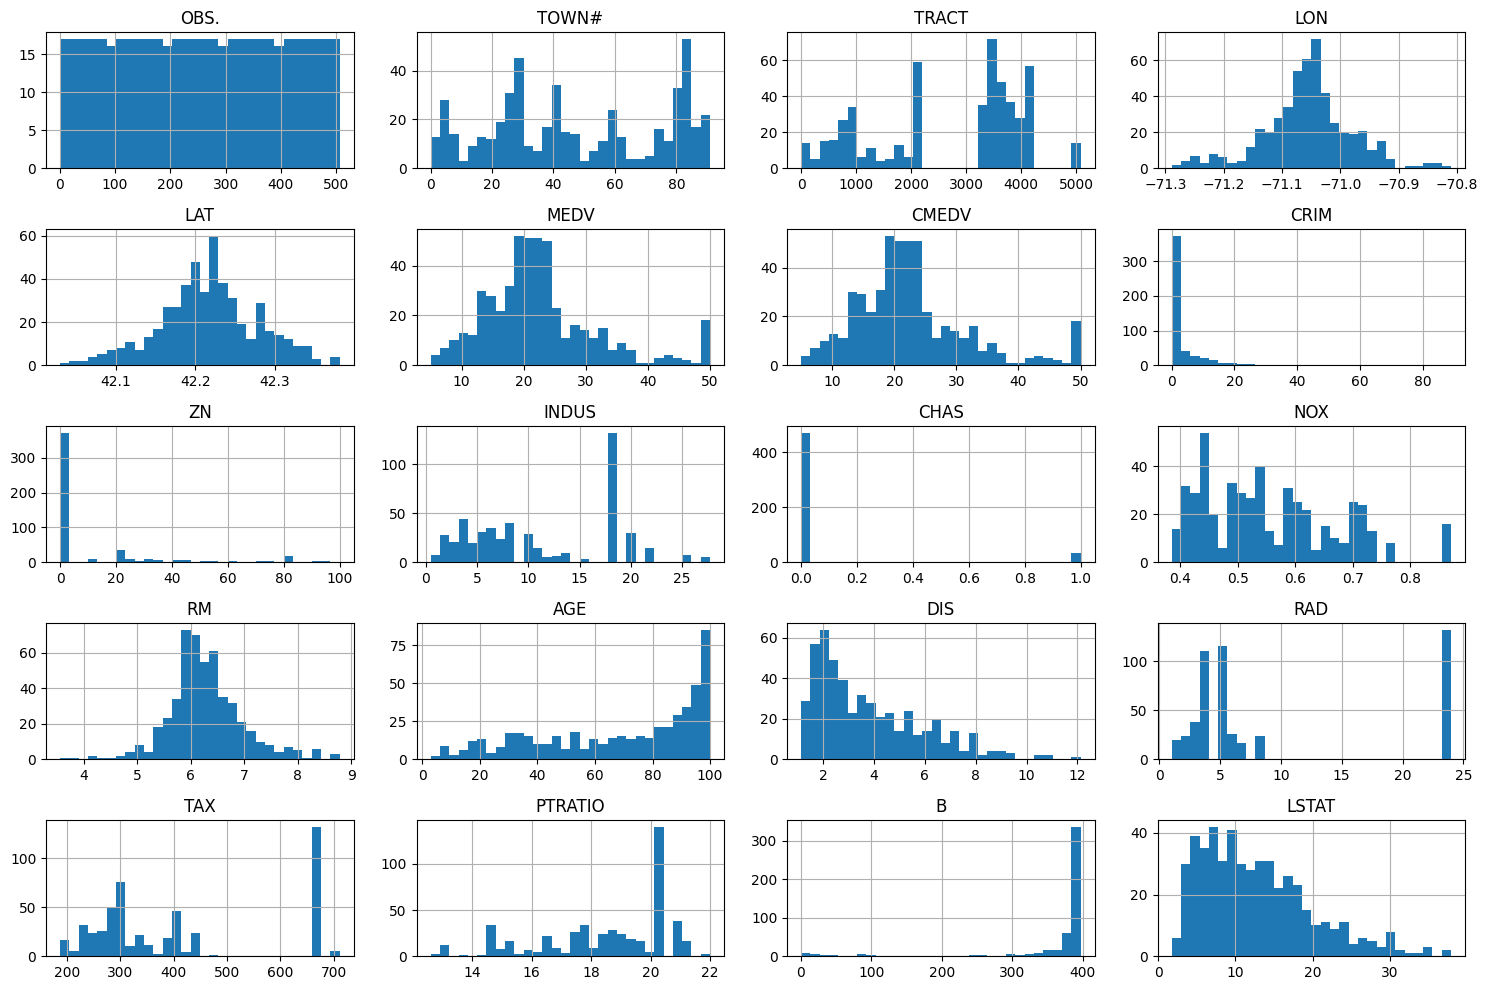

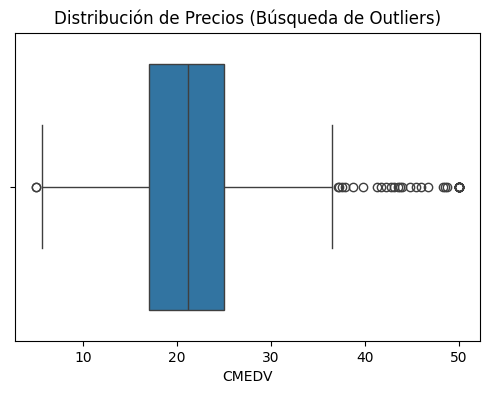

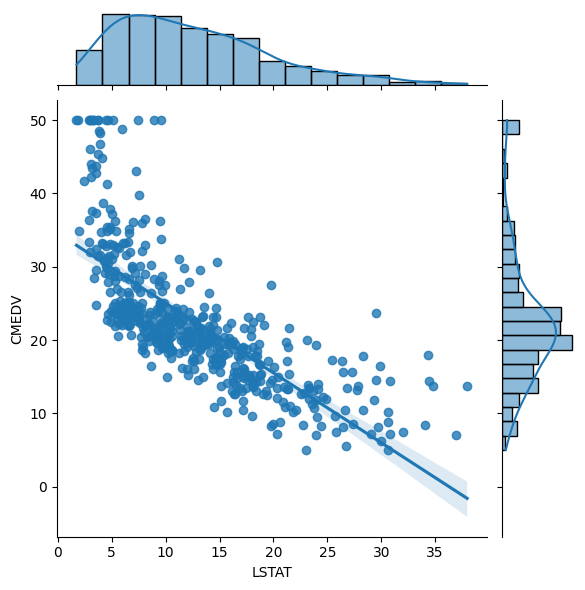

In [67]:
# 1. Histogramas para ver sesgo
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

# 2. Boxplot de la variable objetivo
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['CMEDV'])
plt.title('Distribución de Precios (Búsqueda de Outliers)')
plt.show()

# 3. Scatter plot clave
sns.jointplot(x='LSTAT', y='CMEDV', data=df, kind='reg')
plt.show()

# Modelos para CRIM

In [102]:
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    mean_absolute_percentage_error, median_absolute_error
)

# Rango de Alpha para regularización (desde 0.0001 hasta 100)
param_dist = {'alpha': np.logspace(-4, 2, 100)}

def train_and_evaluate_v2(X_subset, y):
    X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # IMPORTANTE: Definimos n_iter para evitar el warning previo
    n_pruebas = 100

    models = {
        'Linear': LinearRegression(),
        'Ridge': RandomizedSearchCV(Ridge(), param_dist, n_iter=n_pruebas, cv=5, random_state=42),
        'Lasso': RandomizedSearchCV(Lasso(), param_dist, n_iter=n_pruebas, cv=5, random_state=42)
    }

    resultados_metrics = []

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

        metrics = {
            'Modelo': name,
            'R2': r2_score(y_test, preds),
            'MAE': mean_absolute_error(y_test, preds),
            'Best_Alpha': model.best_params_['alpha'] if hasattr(model, 'best_params_') else None
        }
        resultados_metrics.append(metrics)

    return resultados_metrics, models, scaler

In [105]:
X_subset = df[["RAD", "TAX", "LSTAT", "TRACT", "MEDV", "B", "DIS", "NOX"]]
y = df[["CRIM"]]

resultados = train_and_evaluate_v2(X_subset,y)
resultados

([{'Modelo': 'Linear',
   'R2': 0.5398106106184856,
   'MAE': 2.9418341489207234,
   'Best_Alpha': None},
  {'Modelo': 'Ridge',
   'R2': 0.5341661177415999,
   'MAE': 2.8411790756551807,
   'Best_Alpha': np.float64(100.0)},
  {'Modelo': 'Lasso',
   'R2': 0.5201197686116849,
   'MAE': 2.6521230496127766,
   'Best_Alpha': np.float64(0.7564633275546291)}],
 {'Linear': LinearRegression(),
  'Ridge': RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=100,
                     param_distributions={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
         1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
         3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
         5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
         9.32603347e-04, 1.0722...
         4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
         7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
         1.23284674e+01

In [106]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    # Calculamos el VIF para cada variable
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data.sort_values(by='VIF', ascending=False)

# Pruébalo con tu subset original (antes de escalar)
print("\n--- Análisis de Multicolinealidad (VIF) ---")
print(check_vif(X_subset))


--- Análisis de Multicolinealidad (VIF) ---
  Variable        VIF
7      NOX  49.552027
1      TAX  45.373788
5        B  18.570469
0      RAD  16.615274
3    TRACT  15.128495
4     MEDV  13.268229
2    LSTAT  10.503327
6      DIS   6.734621


In [108]:
X_subset = df[["RAD","LSTAT", "MEDV", "B", "DIS"]]
y = df[["CRIM"]]

resultados = train_and_evaluate_v2(X_subset,y)
resultados

([{'Modelo': 'Linear',
   'R2': 0.5323950744990898,
   'MAE': 2.838006693431754,
   'Best_Alpha': None},
  {'Modelo': 'Ridge',
   'R2': 0.5587527606094996,
   'MAE': 2.7503231477472627,
   'Best_Alpha': np.float64(100.0)},
  {'Modelo': 'Lasso',
   'R2': 0.5201693893480557,
   'MAE': 2.652013438668335,
   'Best_Alpha': np.float64(0.7564633275546291)}],
 {'Linear': LinearRegression(),
  'Ridge': RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=100,
                     param_distributions={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
         1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
         3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
         5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
         9.32603347e-04, 1.0722...
         4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
         7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
         1.23284674e+01, 

In [109]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def check_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X.columns
    # Calculamos el VIF para cada variable
    # vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    return vif_data.sort_values(by='VIF', ascending=False)

# Pruébalo con tu subset original (antes de escalar)
print("\n--- Análisis de Multicolinealidad (VIF) ---")
print(check_vif(X_subset))


--- Análisis de Multicolinealidad (VIF) ---
  Variable        VIF
3        B  15.747656
2     MEDV   8.870609
1    LSTAT   5.493842
4      DIS   4.974740
0      RAD   3.099541


In [111]:
X_subset = df[["RAD","LSTAT", "MEDV", "DIS"]]
y = df[["CRIM"]]

resultados = train_and_evaluate_v2(X_subset,y)
resultados

([{'Modelo': 'Linear',
   'R2': 0.5093137157194216,
   'MAE': 2.950468825771566,
   'Best_Alpha': None},
  {'Modelo': 'Ridge',
   'R2': 0.5333716029604786,
   'MAE': 2.944522080769008,
   'Best_Alpha': np.float64(100.0)},
  {'Modelo': 'Lasso',
   'R2': 0.5082411105499274,
   'MAE': 2.6986575607226233,
   'Best_Alpha': np.float64(0.8697490026177834)}],
 {'Linear': LinearRegression(),
  'Ridge': RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=100,
                     param_distributions={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
         1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
         3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
         5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
         9.32603347e-04, 1.0722...
         4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
         7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
         1.23284674e+01, 

Lo que podriamos probar es hace runa transformacion sobre CRIM ya que CRIM es una variable que su distribucion es 0 y numeros muy pegados a este por lo que a los numeros mas precisos no les da tanta importancia


```
y_log = np.log1p(y)
```





In [97]:
y_log = np.log1p(y)

In [112]:
resultados = train_and_evaluate_v2(X_subset,y_log)
resultados

([{'Modelo': 'Linear',
   'R2': 0.8900080069167595,
   'MAE': 0.27633663699300975,
   'Best_Alpha': None},
  {'Modelo': 'Ridge',
   'R2': 0.8898543066544728,
   'MAE': 0.27702824772588813,
   'Best_Alpha': np.float64(5.336699231206313)},
  {'Modelo': 'Lasso',
   'R2': 0.8904376844075627,
   'MAE': 0.27510438317448466,
   'Best_Alpha': np.float64(0.006579332246575682)}],
 {'Linear': LinearRegression(),
  'Ridge': RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=100,
                     param_distributions={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
         1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
         3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
         5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
         9.32603347e-04, 1.0722...
         4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
         7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
      

In [118]:
X_subset = df[["RAD", "LSTAT", "MEDV", "DIS"]]
y_log = np.log1p(df['CRIM'])

metrics, modelos_entrenados, mi_scaler = train_and_evaluate_v2(X_subset, y_log)

data_nuevos = {
    'RAD': [1, 24, 5, 4, 8],
    'LSTAT': [4.5, 30.2, 12.0, 7.8, 18.5],
    'MEDV': [45.0, 12.5, 22.0, 35.0, 18.0],
    'DIS': [7.5, 1.8, 4.0, 5.2, 2.5]
}
nuevos_datos = pd.DataFrame(data_nuevos)

nuevos_scaled = mi_scaler.transform(nuevos_datos)
pred_log = modelos_entrenados['Lasso'].predict(nuevos_scaled)
pred_real = np.expm1(pred_log)

nuevos_datos['CRIM_Predicho'] = pred_real
nuevos_datos["CRIM_log"] = pred_log

In [119]:
metrics

[{'Modelo': 'Linear',
  'R2': 0.8900080069167595,
  'MAE': 0.27633663699300975,
  'Best_Alpha': None},
 {'Modelo': 'Ridge',
  'R2': 0.8898543066544728,
  'MAE': 0.27702824772588813,
  'Best_Alpha': np.float64(5.336699231206313)},
 {'Modelo': 'Lasso',
  'R2': 0.8904376844075627,
  'MAE': 0.27510438317448466,
  'Best_Alpha': np.float64(0.006579332246575682)}]

In [120]:
nuevos_datos

,RAD,LSTAT,MEDV,DIS,CRIM_Predicho,CRIM_log
0,1,4.5,45.0,7.5,-0.352399,-0.434481
1,24,30.2,12.5,1.8,12.631232,2.612364
2,5,12.0,22.0,4.0,0.502106,0.406868
3,4,7.8,35.0,5.2,0.102438,0.097524
4,8,18.5,18.0,2.5,1.493421,0.913656


# Modelos para CMEDV

In [123]:
X_vivienda = df[["RM", "LSTAT", "PTRATIO", "DIS", "CRIM"]]
y_vivienda = df["CMEDV"]

In [124]:
resultados_cmedv, modelos_cmedv, scaler_cmedv = train_and_evaluate_v2(X_vivienda, y_vivienda)

In [125]:
df_res = pd.DataFrame(resultados_cmedv)
df_res

,Modelo,R2,MAE,Best_Alpha
0,Linear,0.616668,3.475997,NaN
1,Ridge,0.621092,3.451249,14.174742
2,Lasso,0.617446,3.472239,0.013219


---

In [130]:
df_clean = df.copy()

df_clean['RM_LSTAT'] = df['RM'] * df['LSTAT']

# 3. Definimos el nuevo X_subset incluyendo la interacción
X_interaccion = df_clean[["RM", "LSTAT", "PTRATIO", "DIS", "CRIM", "RM_LSTAT"]]
y_interaccion = df_clean["CMEDV"]

# 4. Entrenamos con tu función v2
metrics_int, modelos_int, scaler_int = train_and_evaluate_v2(X_interaccion, y_interaccion)

import pandas as pd
print("--- Resultados con Interacción RM*LSTAT ---")
print(pd.DataFrame(metrics_int))

--- Resultados con Interacción RM*LSTAT ---
   Modelo        R2       MAE  Best_Alpha
0  Linear  0.742205  2.772619         NaN
1   Ridge  0.741696  2.776681    0.141747
2   Lasso  0.741934  2.775048    0.003275
